### FlyWire <-> hemibrain FC1-3 co-clustering

In this notebook, we will co-clustering FC1-3 neurons from the FlyWire with those of the hemibrain dataset using `cocoa`.
This is analogous to the analyses in Figure 6 of [Schlegel _et al._, Nature (2024)](https://www.nature.com/articles/s41586-024-07686-5).

Please note that the annotations have been updated with [Berg _et al._, bioRxiv (2025)](https://www.biorxiv.org/content/10.1101/2025.10.09.680999v1).

This is what you need:
1. Install `cocoa`: `pip install git+https://github.com/flyconnectome/cocoa.git` 
2. Generate a CAVE token. See the [caveclient docs](https://caveconnectome.github.io/CAVEclient/tutorials/authentication/) for details.
3. Create an account at https://neuprint.janelia.org/, get your API token and set as `NEUPRINT_APPLICATION_CREDENTIALS` environment variable. See the [`neuprint-python` docs](https://connectome-neuprint.github.io/neuprint-python/docs/quickstart.html) for details.

In [1]:
import cocoa as cc
import matplotlib.pyplot as plt

We can use `cocoa` to quickly grab annotations for a given dataset:

In [2]:
ann_flywire = cc.FlyWire().get_annotations()
ann_hemibrain = cc.Hemibrain().get_annotations()

ann_flywire.head()

Caching FlyWire annotations for materialization '783'... Done.
Caching hemibrain annotations... Done.


,supervoxel_id,root_id,pos_x,pos_y,pos_z,soma_x,soma_y,soma_z,nucleus_id,flow,...,side,nerve,vfb_id,fbbt_id,status,dimorphism,matching_notes,fru_dsx,synonyms,root_783
0,78112261444987077,720575940628857210,109306.0,50491.0,3960.0,104904.0,47464.0,5461.0,2453924.0,intrinsic,...,left,NaN,fw138205,FBbt_20001935,NaN,isomorphic,NaN,NaN,NaN,720575940628857210
1,82475466912542440,720575940626838909,172029.0,55635.0,1592.0,177472.0,56936.0,1429.0,7393349.0,intrinsic,...,right,NaN,fw000001,NaN,NaN,isomorphic,NaN,NaN,NaN,720575940626838909
2,83038623024880664,720575940626046919,180632.0,58664.0,1925.0,180632.0,58664.0,1925.0,7415038.0,intrinsic,...,right,NaN,fw000002,FBbt_20000538,NaN,isomorphic,NaN,NaN,NaN,720575940626046919
3,79801523353604463,720575940630311383,133800.0,56063.0,1847.0,180728.0,61008.0,1630.0,7415013.0,intrinsic,...,right,NaN,fw000003,FBbt_20000260,NaN,isomorphic,NaN,NaN,NaN,720575940630311383
4,83038554439606237,720575940633370649,180496.0,57448.0,2989.0,180496.0,57448.0,2989.0,7415848.0,intrinsic,...,right,NaN,fw000004,FBbt_00051248,NaN,isomorphic,NaN,NaN,NaN,720575940633370649


By default, the annotations for `FlyWire` and `Hemibrain` are downloaded and cached from [flyconnectome/flywire_annotations](https://github.com/flyconnectome/flywire_annotations).


Co-clusterings in `cocoa` work by defining groups of neurons - one for each dataset or hemisphere - and passing them to a clustering class:

In [3]:
# Grab the FC neurons from among the annotations
fc_flywire = ann_flywire[ann_flywire.hemibrain_type.str.startswith("FC", na=False)]
fc_hemibrain = ann_hemibrain[ann_hemibrain.type.str.startswith("FC", na=False)]

# Define a group of FC neurons on the LHS of FlyWire
flywire_left = cc.FlyWire(label="FwL").add_neurons(
    fc_flywire[(fc_flywire.side == "left")].root_id.values
)

# Define a group of FC neurons on the RHS of FlyWire
flywire_right = cc.FlyWire(label="FwR").add_neurons(
    fc_flywire[(fc_flywire.side == "right")].root_id.values
)

# Define a group of FC neurons on the RHS of the hemibrain dataset
hemibrain_right = cc.Hemibrain(label="HbR").add_neurons(
    fc_hemibrain[(fc_hemibrain.side == "right")].bodyId.values
)

flywire_left, flywire_right, hemibrain_right

(class FlyWire <label=FwL;neurons=117>,
 class FlyWire <label=FwR;neurons=118>,
 class Hemibrain <label=HbR;neurons=125>)

In [4]:
# Combine datasets into a Clustering object and compile the results
cl = cc.Clustering(flywire_left, flywire_right, hemibrain_right).compile()

Compiling connectivity vector for "FwL" (FlyWire) [1/3]
Compiling connectivity vector for "FwR" (FlyWire) [2/3]
Compiling connectivity vector for "HbR" (Hemibrain) [3/3]


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Building across-dataset mapping for FlyWire, Hemibrain... 
  Found 4,051 unique labels covering 52,936 neurons.
All Done.
Combining connectivity vectors...   Using 460 unique labels for clustering.
Done.
Generated a 360 by 920 observation vector.
Using on average 97.5% of neurons' synapses.
Worst case is keeping 89.8% of its synapses.
Calculating cosine distances... Done.
All done.


In [5]:
# The connectivity vector where each row is one of our query neurons and each
# column is that neuron's connectivity to a cross-identified cell type
cl.vect_

downstream                                             \
                         FB4E FB4M FB2B SMP110 FB4J CRE019 SMP143 SMP059   
720575940604064958          0    0    0      0    0      0      0      0   
720575940604065470          0    0   24      0    0      0      0      0   
720575940604709920          0    0    0      0    0      0      1      0   
720575940608279747          0    0    0      0    0      0      0      0   
720575940609370466          0    0   17      0    0      0      0      0   
...                       ...  ...  ...    ...  ...    ...    ...    ...   
5813058388                  0    0    0      0    0      0      0      0   
5813058518                  0    0    0      0    0      0      0      0   
5813080632                  0    0   85      0    0      0      0      0   
5813099653                  3    0    2      0    0      0      0      0   
5813104910                  0    0    7      0    0      0      0      0   

                                   ... upstream                           \
                   LAL187 hDeltaF  ...     FB2M FB2H_a OA-VPM3 FB6X FB6N   
720575940604064958      0       0  ...        1      0       0    0    0   
720575940604065470      0       0  ...        0      7       0    0    0   
720575940604709920      0       0  ...       69     23       0    0    0   
720575940608279747      0       0  ...        0      4       0    0    0   
720575940609370466      0       0  ...        4     10       0    0    0   
...                   ...     ...  ...      ...    ...     ...  ...  ...   
5813058388              0       0  ...        0      0       6    3    6   
5813058518              0       1  ...        5      0       0    1    1   
5813080632              0       0  ...        6      9       7    0    0   
5813099653              0       0  ...       15      1       1    0    0   
5813104910              0       0  ...       26      6       1    0    0   

                                                   
                   SMP384 FB2F_a LAL076 FB5H FB4K  
720575940604064958      0      0      4    0    0  
720575940604065470      0      5      0    0    0  
720575940604709920      0     25      0    4   34  
720575940608279747      0      4      0    1    0  
720575940609370466      0      0      0    0    0  
...                   ...    ...    ...  ...  ...  
5813058388              0      0      5    1    0  
5813058518              0      2      5    3    0  
5813080632              0      8      0    0    0  
5813099653              0     24      0    0    0  
5813104910              1     30      0    2    1  

[360 rows x 920 columns]

In [6]:
# The cosine distances - the index is the neurons' IDs and the columns are the
# neurons' type labels (if they have one)
cl.dists_

,FC2C_FwL,FC1D_FwL,FC2A_FwL,FC3_FwL,FC1D_FwL,"FC1C,FC1E_FwL",FC3_FwL,FC2C_FwL,"FC1A,FC1B,FC1F_FwL","FC1C,FC1E_FwL",...,FC2B_HbR,FC1C_HbR,FC2B_HbR,FC1C_HbR,FC2A_HbR,FC2B_HbR,FC2C_HbR,FC1B_HbR,FC1C_HbR,FC1E_HbR
720575940604064958,0.000000,0.976870,0.655823,0.854771,0.980611,0.857591,0.921245,0.236171,0.972463,0.957213,...,0.456978,0.952072,0.702912,0.909305,0.769595,0.556871,0.151187,0.974635,0.951394,0.957672
720575940604065470,0.976870,0.000000,0.970381,0.643812,0.048715,0.528614,0.698476,0.979871,0.243881,0.227548,...,0.971716,0.520039,0.979223,0.449512,0.972166,0.981805,0.984288,0.231642,0.544577,0.234492
720575940604709920,0.655823,0.970381,0.000000,0.861723,0.962295,0.771897,0.857928,0.599431,0.964045,0.883813,...,0.577115,0.869790,0.259443,0.840329,0.087562,0.467821,0.637022,0.972649,0.893484,0.870859
720575940608279747,0.854771,0.643812,0.861723,0.000000,0.661019,0.722888,0.166935,0.851860,0.537992,0.700630,...,0.882233,0.721532,0.873557,0.673556,0.904310,0.856144,0.873305,0.518308,0.730108,0.656226
720575940609370466,0.980611,0.048715,0.962295,0.661019,0.000000,0.477754,0.728891,0.983261,0.242230,0.208407,...,0.974824,0.478530,0.971101,0.425714,0.965276,0.981029,0.984486,0.239287,0.517591,0.186422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5813058388,0.556871,0.981805,0.467821,0.856144,0.981029,0.872296,0.914574,0.372741,0.976937,0.956472,...,0.143963,0.951821,0.165792,0.933956,0.527797,0.000000,0.393262,0.981796,0.952793,0.953285
5813058518,0.151187,0.984288,0.637022,0.873305,0.984486,0.884726,0.915891,0.155070,0.974461,0.961690,...,0.251534,0.952691,0.597348,0.922942,0.697716,0.393262,0.000000,0.976977,0.954391,0.954139
5813080632,0.974635,0.231642,0.972649,0.518308,0.239287,0.672074,0.610480,0.981172,0.046548,0.491495,...,0.978660,0.634586,0.979255,0.534749,0.971211,0.981796,0.976977,0.000000,0.626620,0.379267
5813099653,0.951394,0.544577,0.893484,0.730108,0.517591,0.104737,0.803178,0.947403,0.715051,0.200098,...,0.948643,0.043143,0.944384,0.084304,0.912118,0.952793,0.954391,0.626620,0.000000,0.216778


The `Clustering` object has a few convenience functions for plotting & analysis:

(-0.1, 2.0)

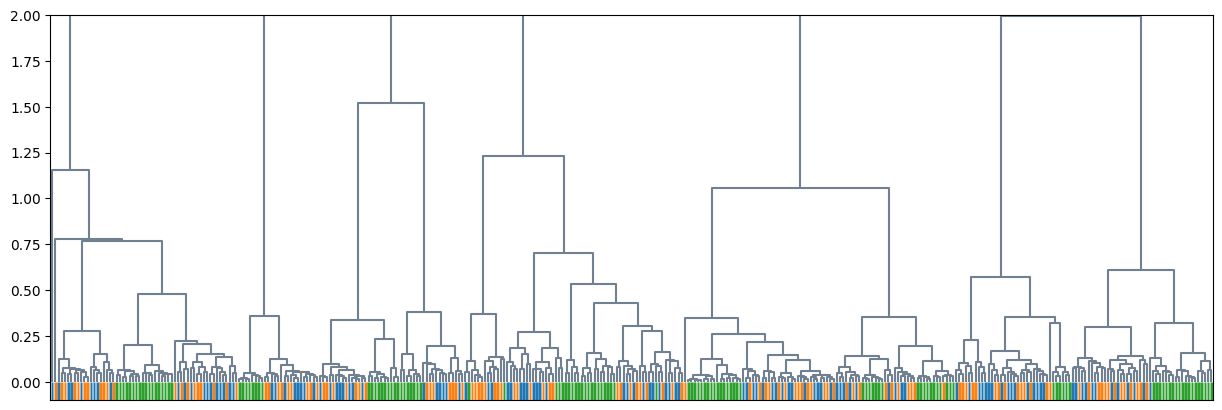

In [7]:
fig, ax = plt.subplots(figsize=(15, 5))

# Plot a dendrogram
dn = cl.plot_dendrogram(ax=ax)

# Zoom-in on the lower part of the dendrogram
ax.set_ylim(top=2)

In above plot, each color corresponds to a dataset:
- FlyWire left/right = orange/blue
- hemibrain = green

/Users/philipps/.pyenv/versions/3.11.8/lib/python3.11/site-packages/umap/umap_.py:1858: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


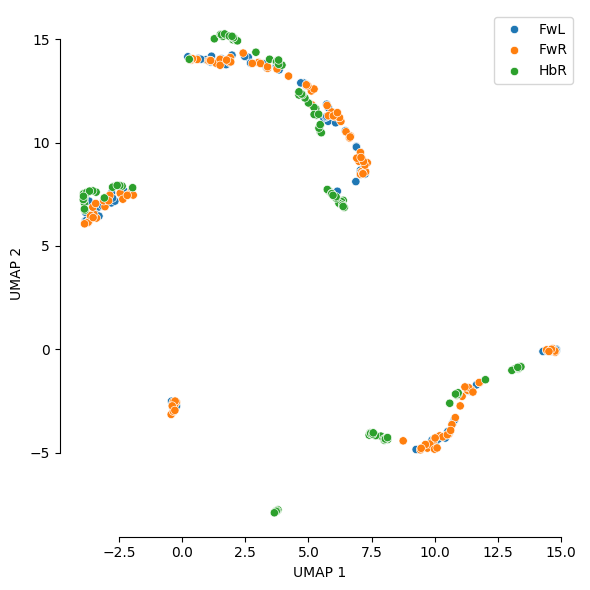

In [8]:
# Alternatively, we can also plot a UMAP projection of the distances
# (requires the `umap-learn` package to be installed)
fig, ax = plt.subplots(figsize=(6, 6))

ax, xy = cl.plot_umap(ax=ax)

In [9]:
# Summarize the clustering results
# The `extract_homogeneous_clusters` will assign clusters based on a homogeneity criterion
# (i.e. each cluster has to contain neurons from each dataset in roughly equal proportions)
table = cl.to_table(clusters=cl.extract_homogeneous_clusters())
table.head()

,id,dataset,label,cn_frac_used,dend_ix,dist_ix,cluster
0,720575940622374783,FwL,FC2C,1.000000,0,49,4
1,720575940629923883,FwR,FC2C,0.942308,1,211,4
2,720575940617296155,FwL,FC2C,0.987342,2,27,4
3,720575940616617245,FwR,FC2C,0.992144,3,146,4
4,720575940627901687,FwR,FC2C,0.988251,4,201,4
